1. Introduction
Apply preprocessing steps following the 2025 ADHD EEG paper methodology.

In [20]:
#기본 라이브러리 임포트
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

# 재현성 확보
np.random.seed(42)
mne.set_log_level('WARNING')

print("Libraries imported successfully")

Libraries imported successfully


2. Loading and Preprocessing Raw Data
   Data Loading: Loaded raw EEG data from .mat format into MNE Raw object (19 channels, 128 Hz).
   Scaling Correction: Fixed unit mismatch by scaling raw values to Volts (multiplied by 1e-6).
   Artifact Suppression: Applied signal clipping at ±300 µV to mitigate the influence of extreme outliers on ICA.
   High-pass Filtering: Applied a 1 Hz high-pass filter (zero-phase FIR) to remove slow drifts, a critical step to improve ICA decomposition quality.
   Validation: Confirmed signal integrity through waveform visualization and Power Spectral Density (PSD) analysis.

>> Status: Successfully completed the first stage of preprocessing. The data is now optimized for ICA-based artifact removal.

final Max amplitude: 80.0 µV
1Hz High-pass complete


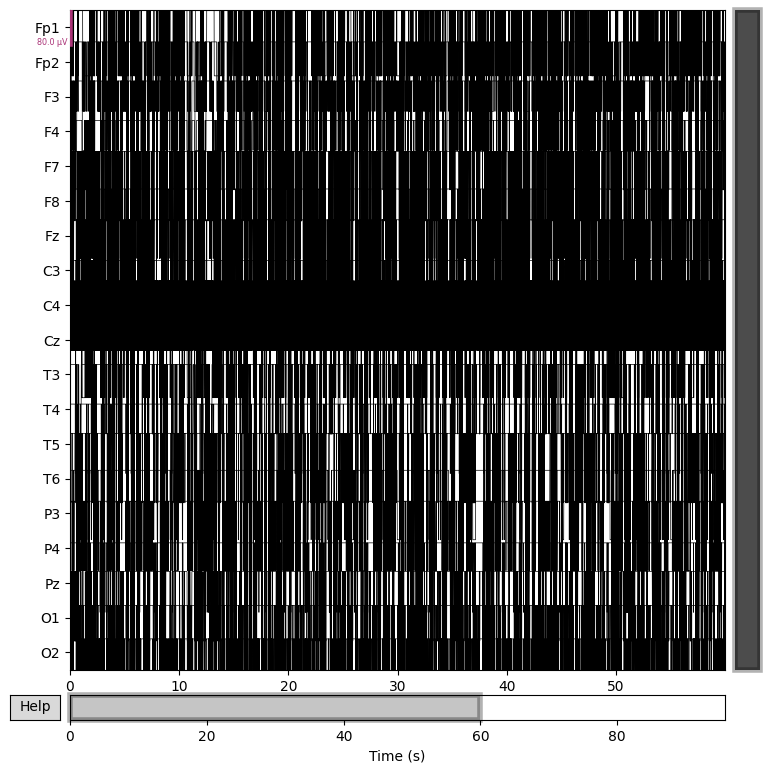

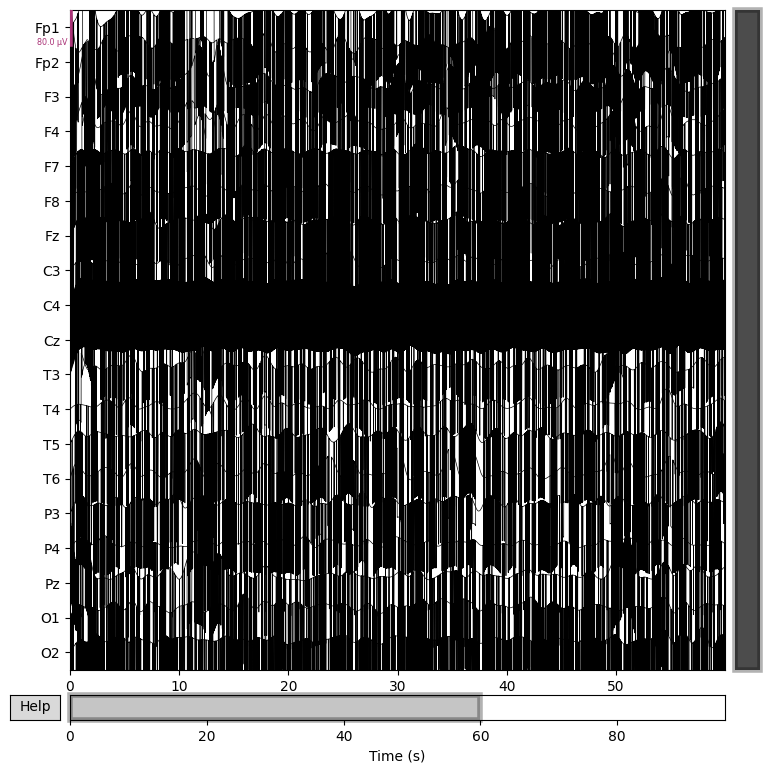

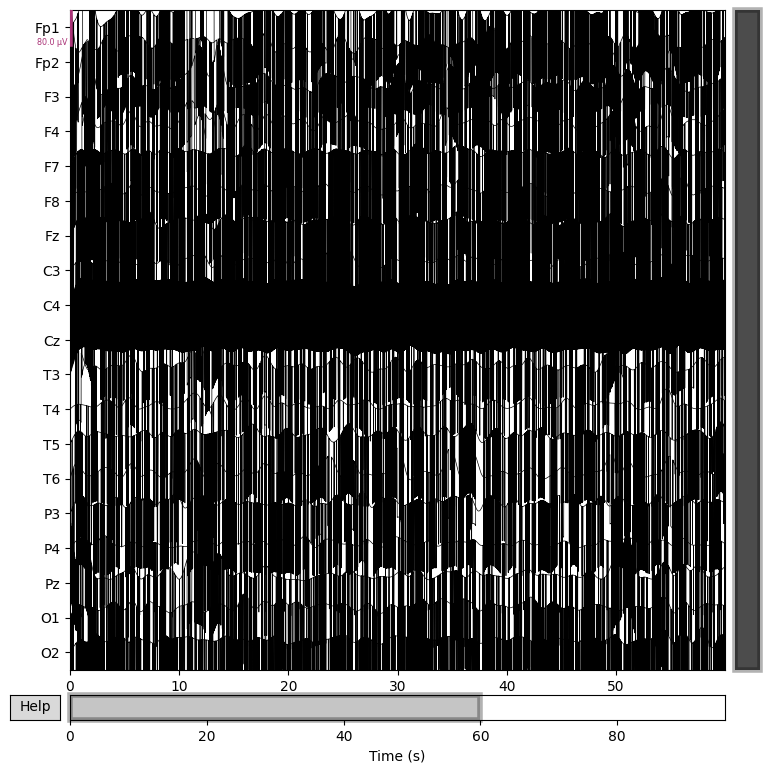

In [39]:
# Raw 로드
raw_path = r'C:\eeg_project\raw_eeg.fif'
raw = mne.io.read_raw_fif(raw_path, preload=True)

# 2. ±80µV 강력 클리핑 (MNE는 Volt 단위이므로 e-6 사용)
data_fixed = np.clip(raw.get_data(), -80e-6, 80e-6)
raw_fixed = raw.copy()
raw_fixed._data = data_fixed

print(f"final Max amplitude: {np.max(np.abs(raw_fixed.get_data())) * 1e6:.1f} µV")

# 3. ICA용 1Hz High-pass 
filt_raw_for_ica = raw_fixed.copy().filter(
    l_freq=1.0,
    h_freq=None,
    fir_design='firwin',
    phase='zero-double',
    picks='eeg'
)
print("1Hz High-pass complete")

# Plot

# 40e-6은 한 칸에 40µV라는 뜻입니다. 파형이 너무 작으면 20e-6으로 줄이기
my_scalings = dict(eeg=40e-6) 

raw_fixed.plot(
    duration=60,
    n_channels=19,
    scalings=my_scalings,  # 'auto' 대신 직접 지정
    title="Raw (Clipped ±80µV)",
    show=True
)

filt_raw_for_ica.plot(
    duration=60,
    n_channels=19,
    scalings=my_scalings,  # 'auto' 대신 직접 지정
    title="1Hz High-pass (for ICA)",
    show=True
)

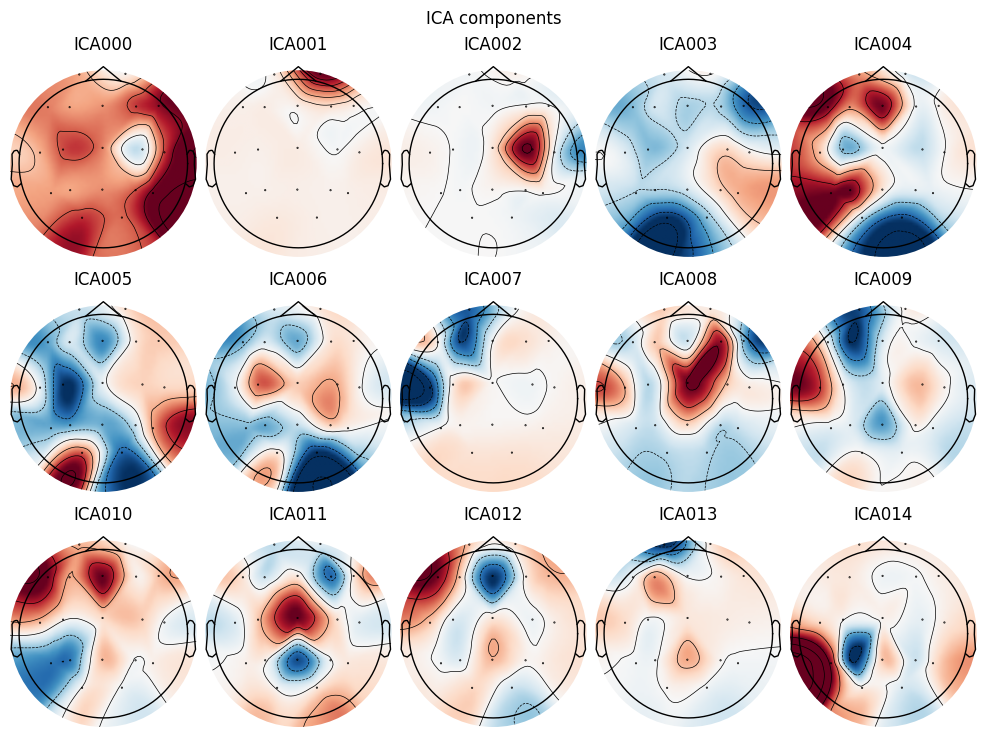

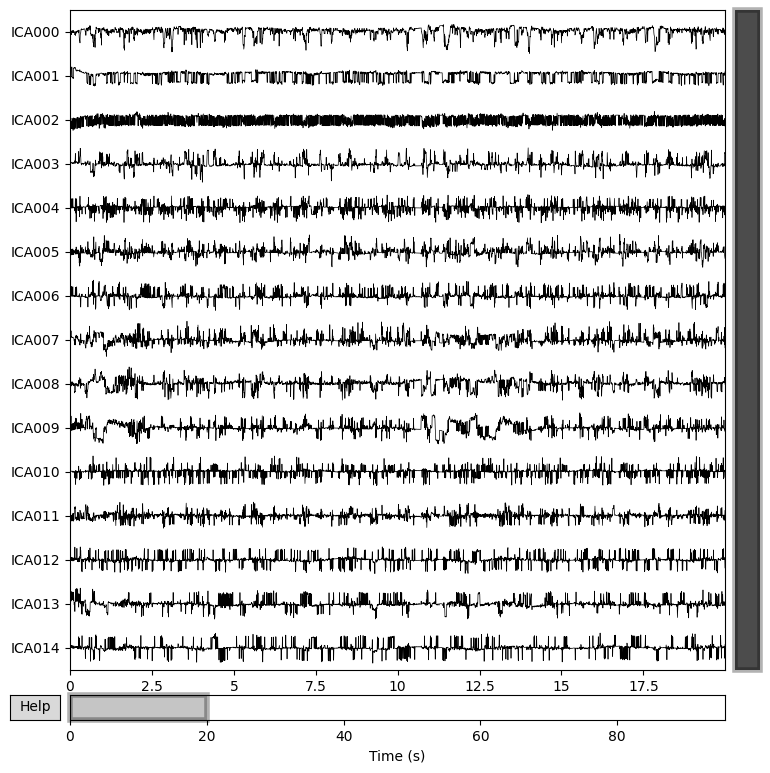

ICA fitting completed.


In [40]:
# 전극 배치도 적용
montage = mne.channels.make_standard_montage('standard_1020')
filt_raw_for_ica.set_montage(montage) # 1Hz 필터된 데이터에 적용

ica = mne.preprocessing.ICA(n_components=15, random_state=42, max_iter="auto")
ica.fit(filt_raw_for_ica)

# 4. 시각화
ica.plot_components() #Topomap
ica.plot_sources(filt_raw_for_ica) # 성분별 파형 (눈 깜빡임 찾기용)

print("ICA fitting completed.")

3. ICA Artifact Removal
Remove ocular (eye blink) and muscle artifacts using Independent Component Analysis.

In [41]:
# Artifact 제거 적용 
ica.exclude = [0, 1, 5, 7, 9, 12]        

raw_clean = ica.apply(raw_fixed.copy())

print(f"ICA artifact removal completed. Excluded components: {ica.exclude}")

ICA artifact removal completed. Excluded components: [0, 1, 5, 7, 9, 12]


4. Post-Preprocessing Visualization
Compare PSD and raw signals before vs after preprocessing.

C:\Users\박지연\AppData\Roaming\Python\Python311\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
C:\Users\박지연\AppData\Roaming\Python\Python311\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


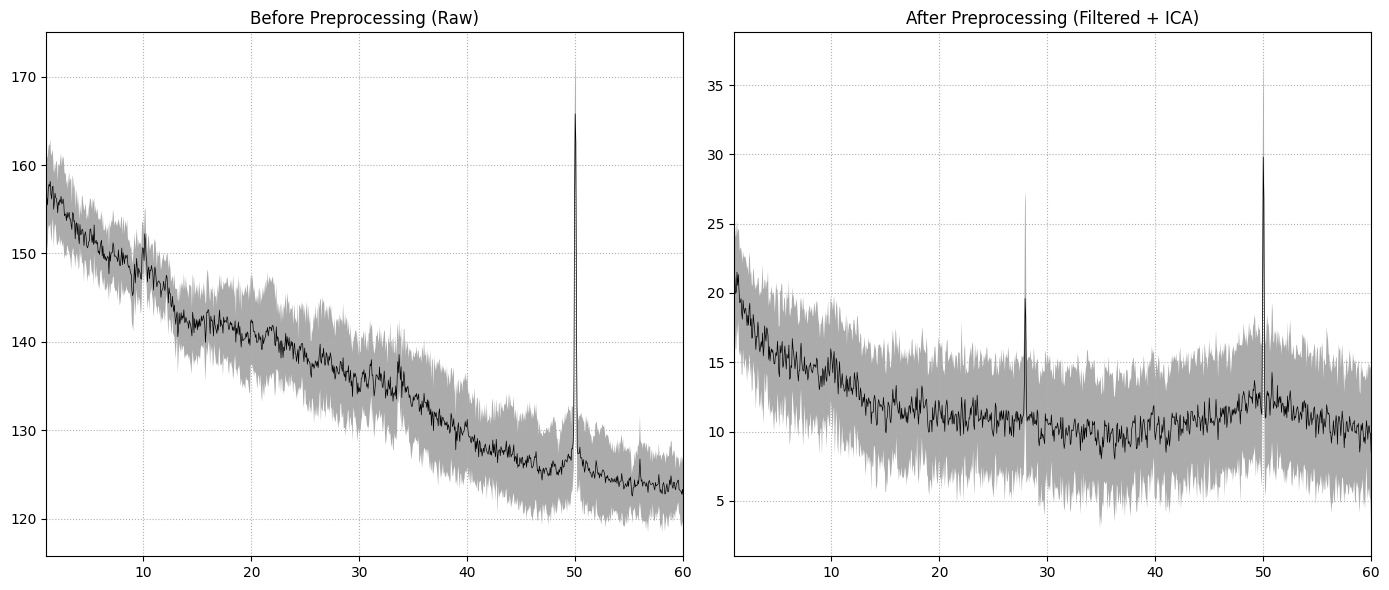

In [42]:
#  Post-Preprocessing Visualization 

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

raw.plot_psd(ax=axs[0], fmin=1, fmax=60, average=True)
axs[0].set_title('Before Preprocessing (Raw)')

raw_clean.plot_psd(ax=axs[1], fmin=1, fmax=60, average=True)
axs[1].set_title('After Preprocessing (Filtered + ICA)')

plt.tight_layout()
plt.show()

5. Final Band-pass Filtering: Re-filtered the cleaned signal with a 4-40 Hz band-pass filter (Theta to Gamma range). This removes the 1 Hz bias used for ICA and focuses on the frequency bands relevant to ADHD research.

ICA 적용 및 4-40Hz Bandpass comeplete


C:\Users\박지연\AppData\Local\Temp\ipykernel_23644\179070137.py:17: RuntimeWarning: The legacy plot_psd() method got an unexpected keyword argument 'axes', which is a parameter of Spectrum.plot(). Try rewriting as object.compute_psd(...).plot(..., axes=<whatever>).
  raw.plot_psd(fmin=1, fmax=60, axes=axs[0], show=False, average=True)
C:\Users\박지연\AppData\Local\Temp\ipykernel_23644\179070137.py:21: RuntimeWarning: The legacy plot_psd() method got an unexpected keyword argument 'axes', which is a parameter of Spectrum.plot(). Try rewriting as object.compute_psd(...).plot(..., axes=<whatever>).
  raw_clean.plot_psd(fmin=1, fmax=60, axes=axs[1], show=False, average=True)


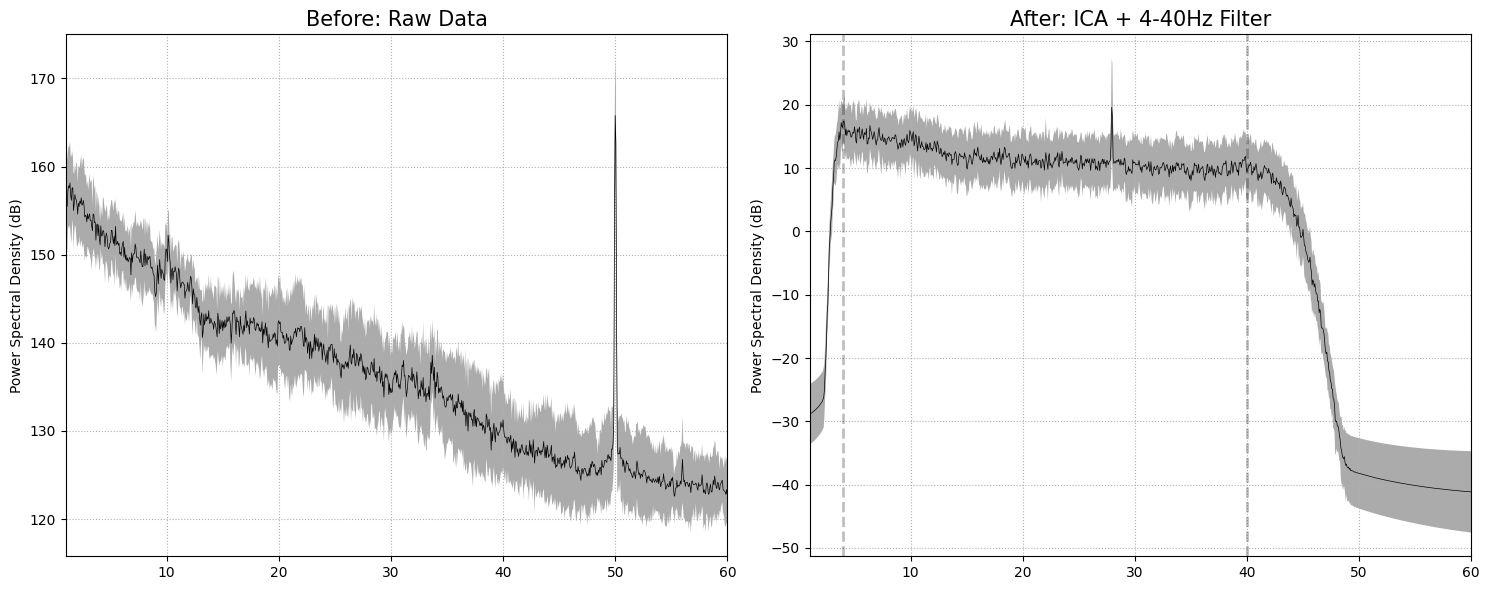

In [43]:
# ICA 적용 
raw_clean = ica.apply(raw_fixed.copy())

# 4-40Hz Bandpass
raw_clean.filter(
    l_freq=4.0, 
    h_freq=40.0, 
    fir_design='firwin', 
    phase='zero-double'
)

print("ICA 적용 및 4-40Hz Bandpass comeplete")


fig, axs = plt.subplots(1, 2, figsize=(15, 6))

raw.plot_psd(fmin=1, fmax=60, axes=axs[0], show=False, average=True)
axs[0].set_title('Before: Raw Data', fontsize=15)
axs[0].set_ylabel('Power Spectral Density (dB)')

raw_clean.plot_psd(fmin=1, fmax=60, axes=axs[1], show=False, average=True)
axs[1].set_title('After: ICA + 4-40Hz Filter', fontsize=15)
axs[1].set_ylabel('Power Spectral Density (dB)')

plt.tight_layout()
plt.show()

In [48]:
# Theta(4-8Hz) 대역의 평균 파워
psds, freqs = raw_clean.compute_psd(fmin=4, fmax=8).get_data(return_freqs=True)
theta_power_mean = psds.mean()
print(f"평균 Theta 파워: {theta_power_mean:.2e}")

theta_db = 10 * np.log10(4.59e-11)
print(f"Theta 파워(dB): {theta_db:.2f} dB")

평균 Theta 파워: 4.59e-11
Theta 파워(dB): -103.38 dB


ICA Artifact Rejection Decision

- First trial: Excluded 4 muscle components (ICA005, 007, 009, 012)
- Second trial: Additionally excluded ICA000 and ICA001 (classic ocular artifacts)
- PSD comparison shows clear improvement after removing 6 components total:
  - Significant reduction in low-frequency noise and 50 Hz line noise
  - Smoother 1/f spectral decay while preserving EEG characteristics
- Final decision: Exclude [ICA 000, 001, 005, 007, 009, 012] (6 components)
  
6. Epoch Segmentation
Segment continuous EEG into non-overlapping 2-second epochs.

In [56]:
epochs = mne.make_fixed_length_epochs(
    raw_clean, 
    duration=2.0, 
    overlap=0.0, 
    preload=True
)

print(f"Epoching completed: {len(epochs)} epochs")

data_shape = epochs.get_data(copy=True).shape
print(f"Epoch shape: {data_shape} → (count, channel, sample count)")

# Theta 대역(4-8Hz) PSD 계산
# n_fft를 데이터 샘플 수(256)보다 큰 512로 설정하여 resolution 보간
psd_obj = epochs.compute_psd(
    method='welch',  
    fmin=4, fmax=40, 
    n_fft=512,        # 2초(256샘플)보다 크게 설정하여 Zero-padding 효과
    n_per_seg=256,    # 한 세그먼트 길이는 에포크 전체 길이(2초, 256sample)로 설정
)
psds, freqs = psd_obj.get_data(return_freqs=True)

print(f"PSD shape: {psds.shape} → (epochs, channels, frequency_bins)")
print(f"epochs count: {psds.shape[0]}, channel count: {psds.shape[1]}")

Epoching completed: 47 epochs
Epoch shape: (47, 19, 256) → (count, channel, sample count)
PSD shape: (47, 19, 145) → (epochs, channels, frequency_bins)
epochs count: 47, channel count: 19


In [57]:
# nomalization(db(로그)로 변환)
psds_db = 10 * np.log10(psds)

# 0~1 사이로 Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
psds_flat = psds_db.reshape(len(psds), -1)   # (Epochs, Channels * Bins) 형태로 펴서 스케일링
psds_scaled = scaler.fit_transform(psds_flat)

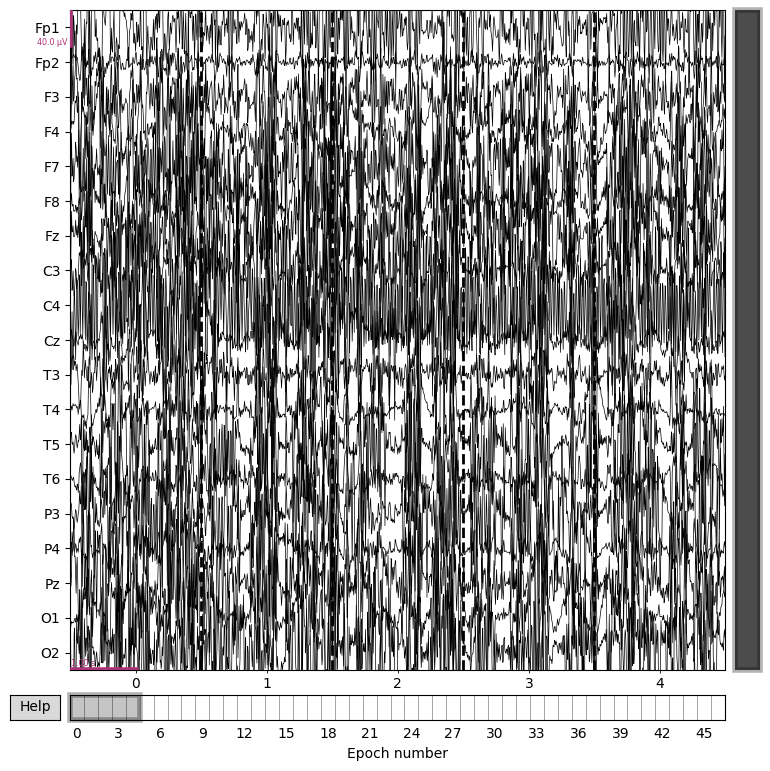

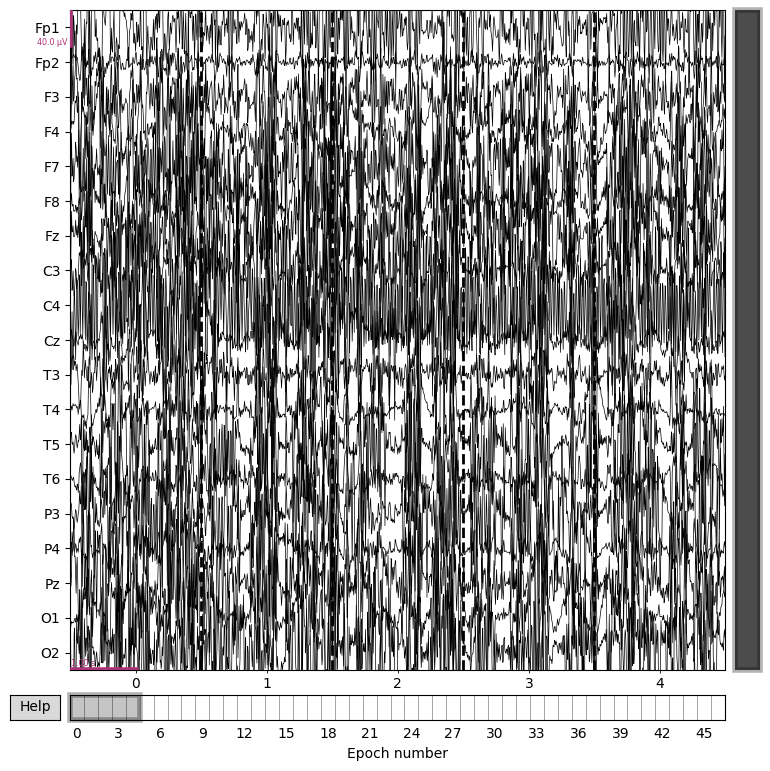

In [58]:
epochs.plot(n_epochs=5, n_channels=19, title="Sample Epochs Check")

7. Summary & Next Steps
Extend preprocessing to the full dataset (all 121 subjects).

8. Extension to Full Dataset
Process all 121 .mat files (61 ADHD + 60 HC) using the validated preprocessing pipeline.

10. Full Dataset Preprocessing Pipeline
- Load all .mat files
- 1 Hz high-pass filter (zero-phase FIR)
- Apply ICA artifact removal (using parameters validated on single subject)
- Apply bandpass filter (4–40 Hz)
- Segment into 2-second non-overlapping epochs
- Save cleaned epochs and labels

In [4]:
import glob
import os
import scipy.io as sio
import numpy as np
from tqdm import tqdm
import mne
from mne.preprocessing import ICA
from mne.io import RawArray

base_dir = r'C:\Users\박지연\OneDrive\바탕 화면\EEG data for ADHD  Control children'

channel_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
                 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

exclude_ica = [0, 1, 5, 7, 9, 12]

mat_files = []
for part in ['ADHD_part1', 'ADHD_part2', 'Control_part1', 'Control_part2']:
    path = os.path.join(base_dir, part)
    if os.path.exists(path):
        files = glob.glob(os.path.join(path, '*.mat'))
        mat_files.extend(files)
        print(f"{part}: {len(files)} files found")
    else:
        print(f"{part} 폴더를 찾을 수 없음")

print(f"\nTotal files found: {len(mat_files)}")

# processing
all_psds = []
all_labels = []

for file_path in tqdm(sorted(mat_files), desc="Processing"):
    try:
        mat = sio.loadmat(file_path)
        data_key = [k for k in mat.keys() if not k.startswith('__')][0]
        raw_data = mat[data_key].T
       
        info = mne.create_info(channel_names, sfreq=128, ch_types='eeg')
        raw = RawArray(raw_data, info, verbose=False)
       
        raw.filter(4.0, 40.0, fir_design='firwin', verbose=False)
       
        ica = ICA(n_components=15, random_state=42, max_iter=250,
                  method='fastica', verbose=False)
        ica.fit(raw, verbose=False)
        ica.exclude = exclude_ica
        raw_clean = ica.apply(raw.copy(), verbose=False)
       
        epochs = mne.make_fixed_length_epochs(raw_clean, duration=2.0,
                                              preload=True, verbose=False)
       
        if len(epochs) > 0:
            psd_obj = epochs.compute_psd(method='welch', fmin=4, fmax=40,
                                         n_fft=512, n_per_seg=256, verbose=False)
            psds, _ = psd_obj.get_data(return_freqs=True)
            
            # PSD 데이터 추가
            all_psds.append(10 * np.log10(psds))
            
            # Label 결정 
            parent_folder = os.path.basename(os.path.dirname(file_path)).upper()
            
            if 'ADHD' in parent_folder:
                label = 1
            elif 'CONTROL' in parent_folder:    #upper 썼으니까 대문자 상관 x
                label = 0
            else:
                filename = os.path.basename(file_path).upper()
                label = 1 if ('ADHD' in filename) else 0

            all_labels.extend([label] * len(psds))          # psds 개수만큼 라벨을 복사해서 추가
            
            # 디버깅 출력
            if len(all_labels) <= 100: 
                print(f"File: {os.path.basename(file_path):<35} → Label: {label}")
                
    except Exception as e:
        print(f"Error in {os.path.basename(file_path)}: {e}")
        continue

# 최종 저장 
if all_psds:
    X = np.concatenate(all_psds, axis=0)
    y = np.array(all_labels)
    X_flat = X.reshape(X.shape[0], -1)
   
    np.save('X_full_dataset.npy', X_flat)
    np.save('y_full_dataset.npy', y)
   
    print("=" * 80)
    print(f"   X_flat shape : {X_flat.shape}")
    print(f"   ADHD epochs  : {sum(y)}")
    print(f"   HC epochs    : {len(y) - sum(y)}")
    print(f"   ADHD 비율    : {sum(y)/len(y)*100:.1f}%")
    print("=" * 80)
else:
    print("couldn't find dataset")

ADHD_part1: 30 files found
ADHD_part2: 31 files found
Control_part1: 30 files found
Control_part2: 30 files found

Total files found: 121


Processing:   1%|▌                                                                     | 1/121 [00:00<00:53,  2.26it/s]

File: v10p.mat                            → Label: 1


Processing:  21%|██████████████▎                                                      | 25/121 [00:18<00:58,  1.63it/s]C:\ProgramData\anaconda3\envs\eeg_adhd\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
Processing:  35%|███████████████████████▉                                             | 42/121 [00:31<00:53,  1.49it/s]C:\ProgramData\anaconda3\envs\eeg_adhd\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
Processing:  56%|██████████████████████████████████████▊                              | 68/121 [00:54<00:30,  1.74it/s]C:\ProgramData\anaconda3\envs\eeg_adhd\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum numb

   X_flat shape : (8400, 2755)
   ADHD epochs  : 4683
   HC epochs    : 3717
   ADHD 비율    : 55.8%
